In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from helpers import load_result

In [2]:
msmarco_eps_greedy_e01_lambda05_path = "../results/EpsilonGreedy_e=0.1_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"
msmarco_ucb_c2_lambda05_path = "../results/UCB_c=2.0_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"
msmarco_thompson_lambda05_path = "../results/ThompsonSampling_lambda=0.5_metric=recall_seed=42_dataset=ms_marco.json"

msmarco_eps_greedy_e01_lambda05_results = load_result(msmarco_eps_greedy_e01_lambda05_path)
msmarco_ucb_c2_lambda05_results = load_result(msmarco_ucb_c2_lambda05_path)
msmarco_thompson_lambda05_results = load_result(msmarco_thompson_lambda05_path)

nq_eps_greedy_e01_lambda05_path = "../results/EpsilonGreedy_e=0.1_lambda=0.5_metric=recall_seed=42_dataset=nq.json"
nq_ucb_c2_lambda05_path = "../results/UCB_c=2.0_lambda=0.5_metric=recall_seed=42_dataset=nq.json"
nq_thompson_lambda05_path = "../results/ThompsonSampling_lambda=0.5_metric=recall_seed=42_dataset=nq.json"

nq_eps_greedy_e01_lambda05_results = load_result(nq_eps_greedy_e01_lambda05_path)
nq_ucb_c2_lambda05_results = load_result(nq_ucb_c2_lambda05_path)
nq_thompson_lambda05_results = load_result(nq_thompson_lambda05_path)

In [3]:
RESULTS_DIR = "../images"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [16]:
def arm_performance_violinplot(data: dict, title: str, save_path: str):
    """Show score distribution for each arm using violin plot"""
    scores = np.array(data['scores'])
    selected_arms = np.array(data['selected_arms'])
    arm_names = [data['arm_map'][str(i)] for i in range(len(data['arm_map']))]
    n_arms = len(arm_names)
    
    # Prepare data for violin plot
    arm_scores = [scores[selected_arms == i] for i in range(n_arms)]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Create violin plot
    parts = ax.violinplot(arm_scores, 
                          positions=range(n_arms),
                          showmeans=True, 
                          showmedians=True,
                          showextrema=True)
    
    # Customize violin colors
    colors = plt.cm.Set3(range(n_arms))
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.9)
    
    # Customize the mean/median lines
    parts['cmeans'].set_color('red')
    parts['cmeans'].set_linewidth(2)
    parts['cmedians'].set_color('blue')
    parts['cmedians'].set_linewidth(2)
    
    # Add selection counts on top
    for i, arm_id in enumerate(range(n_arms)):
        count = len(arm_scores[arm_id])
        mean_score = np.mean(arm_scores[arm_id]) if count > 0 else 0
        ax.text(i, 1.05, f'n={count}', 
                ha='center', va='bottom', fontsize=8)
    
    # Labels and formatting
    ax.set_xticks(range(n_arms))
    ax.set_xticklabels(arm_names, fontsize=8)
    ax.set_ylabel('Recall Score')
    ax.set_xlabel('Selected Arm')
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-0.05, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    # Add legend for mean/median
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', linewidth=2, label='Mean'),
        Line2D([0], [0], color='blue', linewidth=2, label='Median')
    ]
    ax.legend(handles=legend_elements, loc='best')
    
    # Save and show plot
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

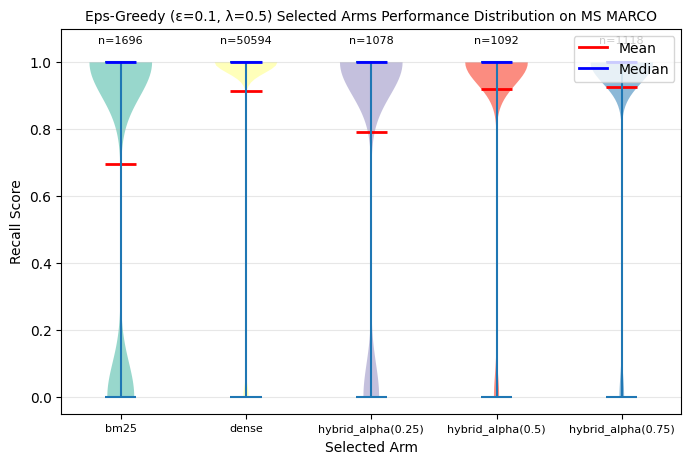

In [17]:
arm_performance_violinplot(msmarco_eps_greedy_e01_lambda05_results,
                           title = "Eps-Greedy (ε=0.1, λ=0.5) Selected Arms Performance Distribution on MS MARCO",
                           save_path = os.path.join(RESULTS_DIR, "msmarco_eps_greedy_e01_lambda05_violinplot.png"))
                           

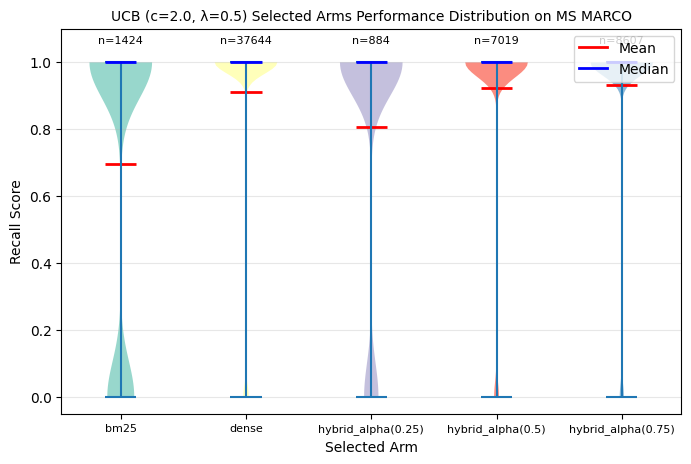

In [18]:
arm_performance_violinplot(msmarco_ucb_c2_lambda05_results,
                           title = "UCB (c=2.0, λ=0.5) Selected Arms Performance Distribution on MS MARCO",
                           save_path = os.path.join(RESULTS_DIR, "msmarco_ucb_c2_lambda05_violinplot.png"))

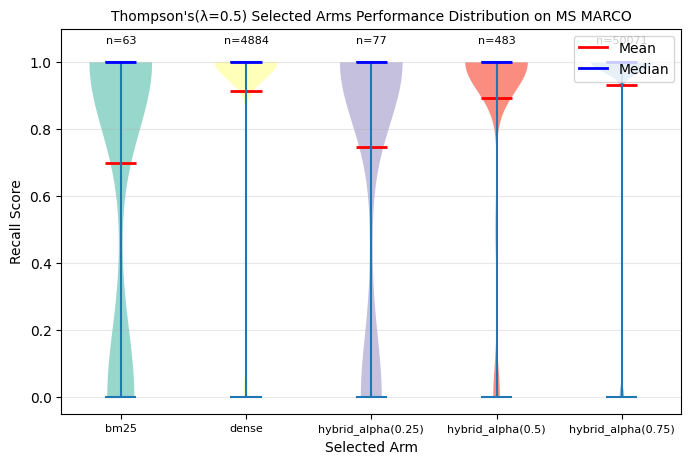

In [19]:
arm_performance_violinplot(msmarco_thompson_lambda05_results,
                           title = "Thompson\'s(λ=0.5) Selected Arms Performance Distribution on MS MARCO",
                            save_path = os.path.join(RESULTS_DIR, "msmarco_thompson_lambda05_violinplot.png"))

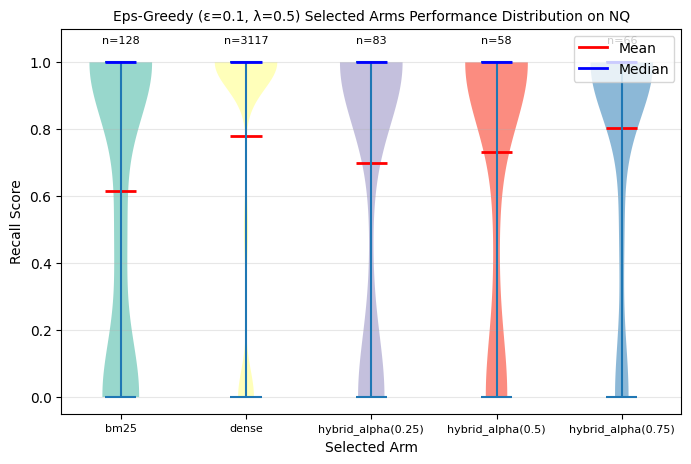

In [20]:
arm_performance_violinplot(nq_eps_greedy_e01_lambda05_results,
                           title = "Eps-Greedy (ε=0.1, λ=0.5) Selected Arms Performance Distribution on NQ",
                           save_path = os.path.join(RESULTS_DIR, "nq_eps_greedy_e01_lambda05_violinplot.png"))

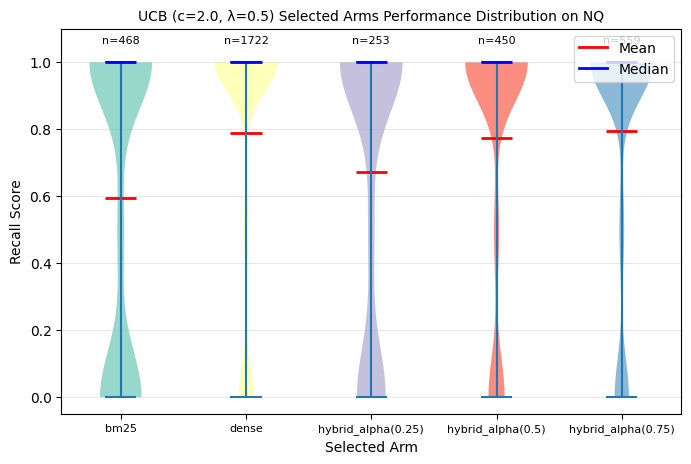

In [21]:
arm_performance_violinplot(nq_ucb_c2_lambda05_results,
                           title = "UCB (c=2.0, λ=0.5) Selected Arms Performance Distribution on NQ",
                           save_path = os.path.join(RESULTS_DIR, "nq_ucb_c2_lambda05_violinplot.png"))

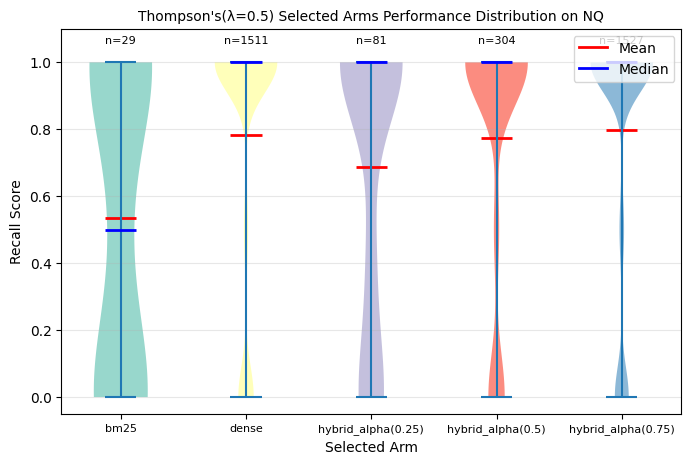

In [22]:
arm_performance_violinplot(nq_thompson_lambda05_results,
                           title = "Thompson\'s(λ=0.5) Selected Arms Performance Distribution on NQ",
                           save_path = os.path.join(RESULTS_DIR, "nq_thompson_lambda05_violinplot.png"))